In [1]:
# python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from hist import intervals
import coffea.util
# import numpy as np
import mplhep as hep
import numpy as np
import warnings

In [2]:
import yaml
yaml_file_path = '../../configs/ntuples/signal_2mu2e_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_all = list(data["llpNanoAOD_v2"]["samples"].keys())
for x in range(len(signals_all)):
    # if x == 0:
    print("'" + signals_all[x] + "',")


'2Mu2E_100GeV_0p25GeV_0p02mm',
'2Mu2E_100GeV_0p25GeV_0p2mm',
'2Mu2E_100GeV_0p25GeV_2p0mm',
'2Mu2E_100GeV_0p25GeV_10p0mm',
'2Mu2E_100GeV_0p25GeV_20p0mm',
'2Mu2E_100GeV_1p2GeV_0p096mm',
'2Mu2E_100GeV_1p2GeV_0p96mm',
'2Mu2E_100GeV_1p2GeV_9p6mm',
'2Mu2E_100GeV_1p2GeV_48p0mm',
'2Mu2E_100GeV_1p2GeV_96p0mm',
'2Mu2E_100GeV_5p0GeV_0p4mm',
'2Mu2E_100GeV_5p0GeV_4p0mm',
'2Mu2E_100GeV_5p0GeV_40p0mm',
'2Mu2E_100GeV_5p0GeV_200mm',
'2Mu2E_100GeV_5p0GeV_400mm',
'2Mu2E_150GeV_0p25GeV_0p013mm',
'2Mu2E_150GeV_0p25GeV_0p13mm',
'2Mu2E_150GeV_0p25GeV_1p3mm',
'2Mu2E_150GeV_0p25GeV_6p7mm',
'2Mu2E_150GeV_0p25GeV_13p0mm',
'2Mu2E_150GeV_1p2GeV_0p064mm',
'2Mu2E_150GeV_1p2GeV_0p64mm',
'2Mu2E_150GeV_1p2GeV_6p4mm',
'2Mu2E_150GeV_1p2GeV_32p0mm',
'2Mu2E_150GeV_1p2GeV_64p0mm',
'2Mu2E_150GeV_5p0GeV_0p27mm',
'2Mu2E_150GeV_5p0GeV_2p7mm',
'2Mu2E_150GeV_5p0GeV_27p0mm',
'2Mu2E_150GeV_5p0GeV_130p0mm',
'2Mu2E_150GeV_5p0GeV_270p0mm',
'2Mu2E_200GeV_0p25GeV_0p01mm',
'2Mu2E_200GeV_0p25GeV_0p1mm',
'2Mu2E_200GeV_0p25GeV_1p0mm',
'2Mu2

In [3]:
QCD=[ 
     "QCD_Pt15To20", 
     "QCD_Pt20To30",
     "QCD_Pt30To50",
     "QCD_Pt50To80",
     "QCD_Pt80To120",
     "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
     "QCD_Pt470To600",
     "QCD_Pt600To800",
    "QCD_Pt800To1000",
     "QCD_Pt1000",
    ]
DY = [ 
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
    #  
]
TT = [ 
    "TTJets",
     ]

bgs=  TT + QCD + DY





0 mulj_egmlj_invmass


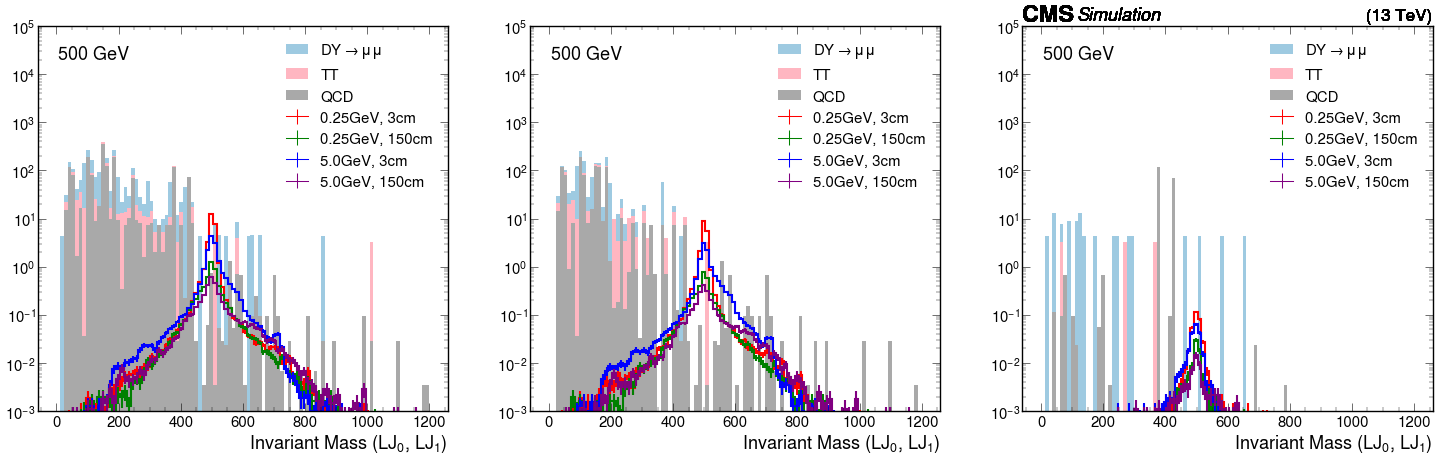

1 mu_lj_pfMuon_dxy_XLowRange


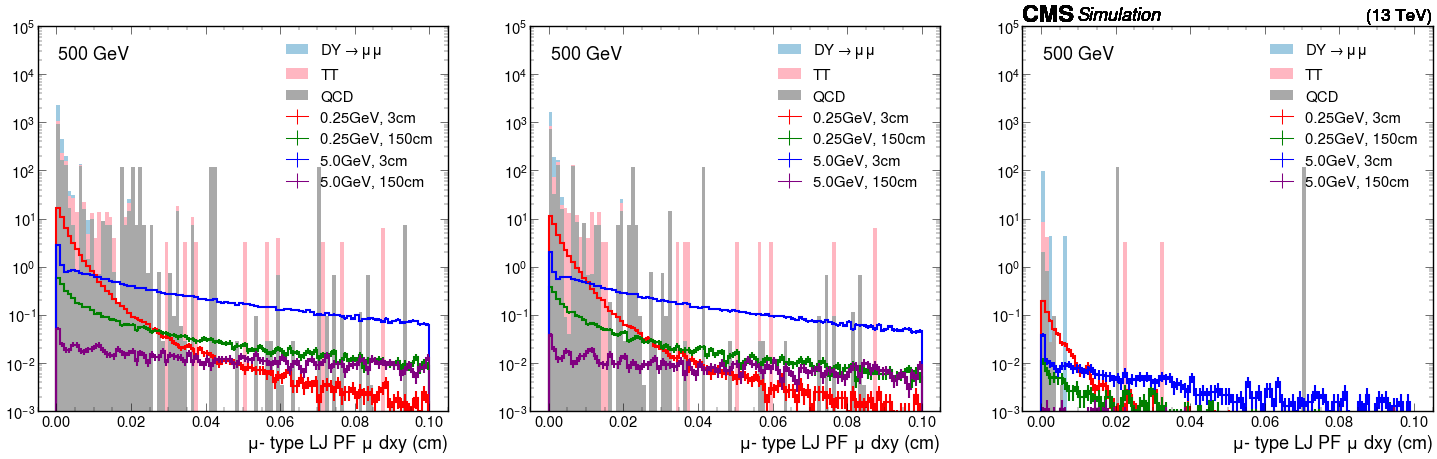

2 mu_lj_pfMuon_max_dxy_XLowRange


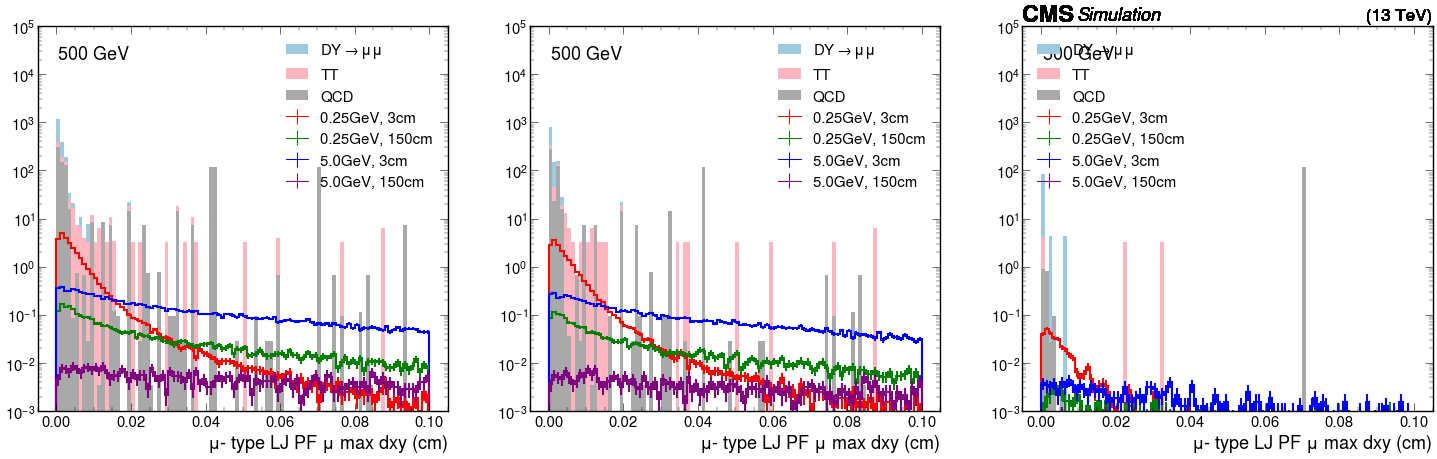

3 mu_lj_pfMuon_min_dxy_XLowRange


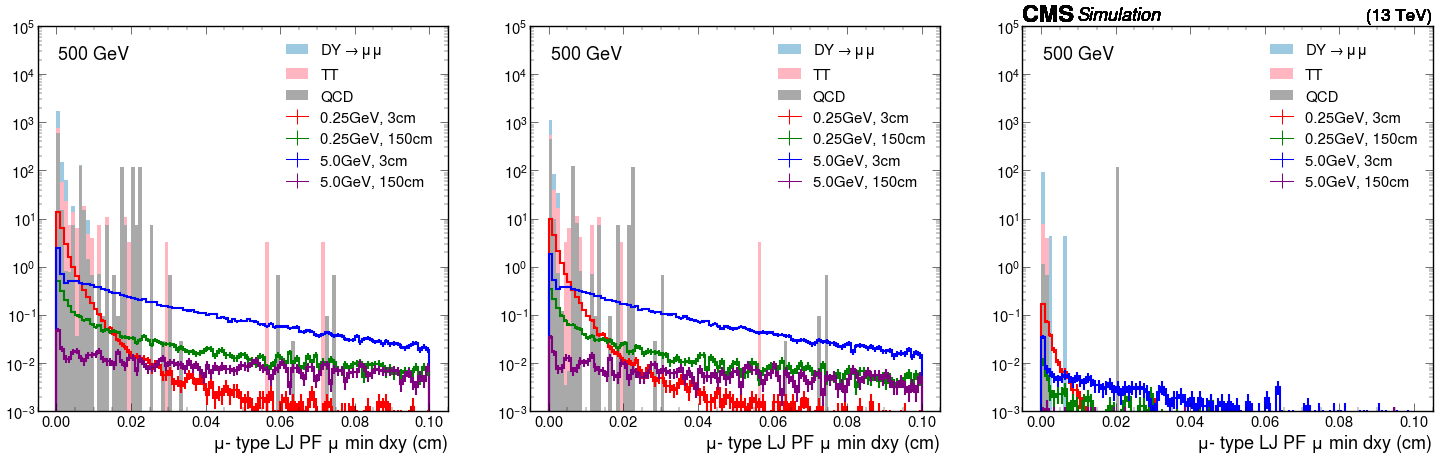

4 egm_lj_electron_dxy_XXXLowRange


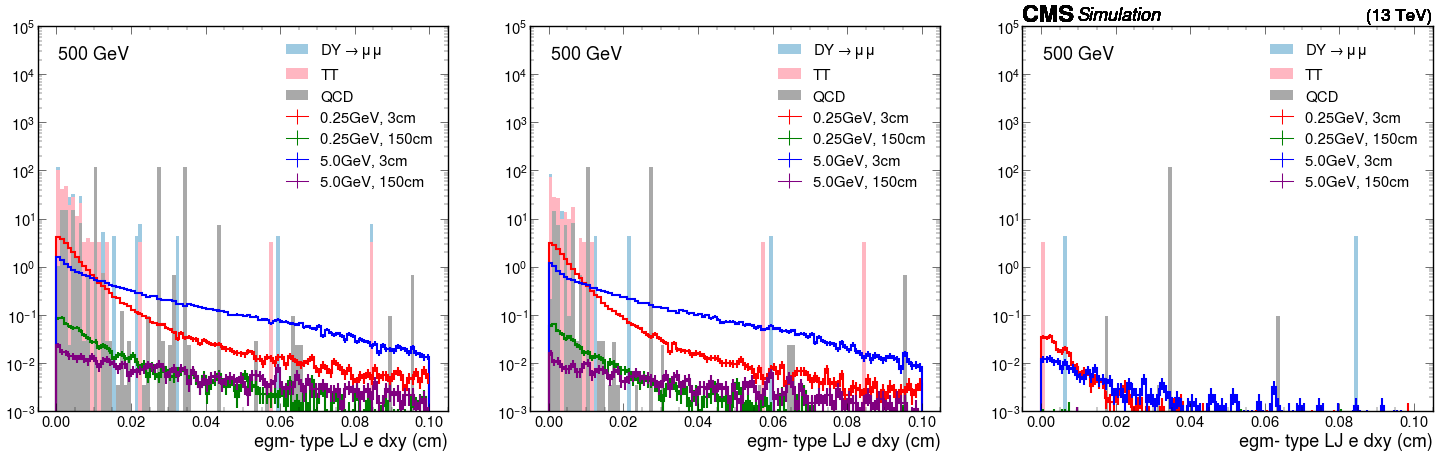

5 egm_lj_electron_max_dxy_XXXLowRange


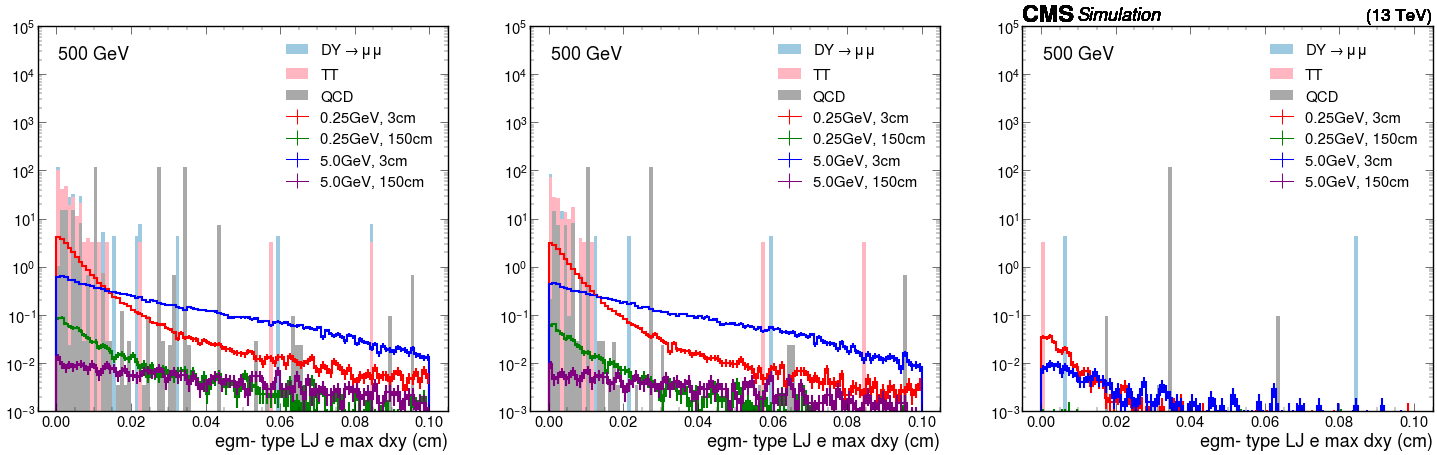

6 egm_lj_electron_min_dxy_XXXLowRange


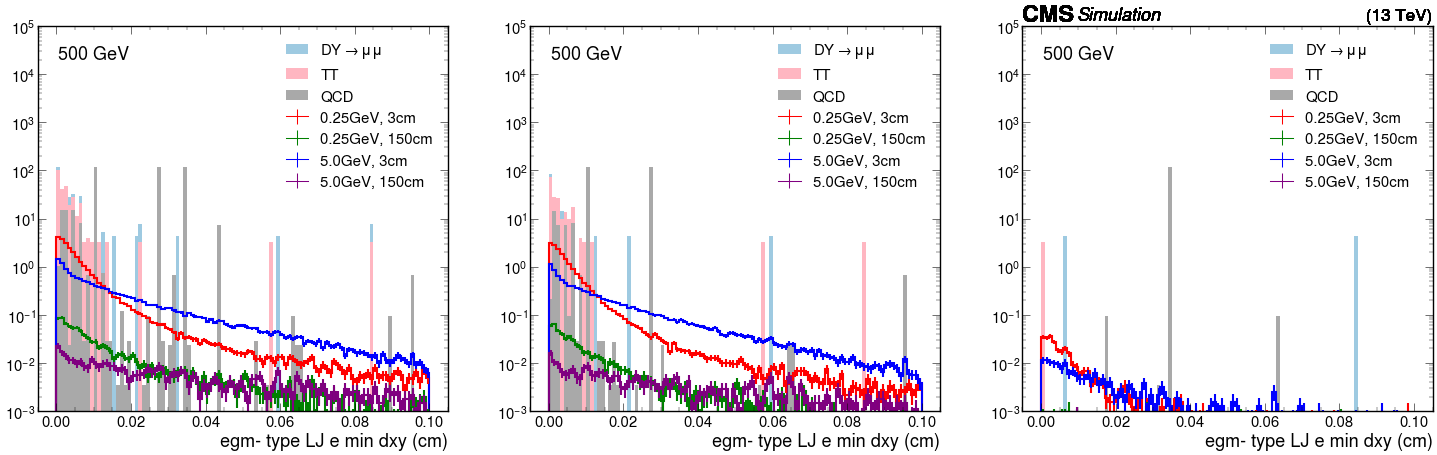

7 mulj_egmlj_invmass_pixelHits_lostHits


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


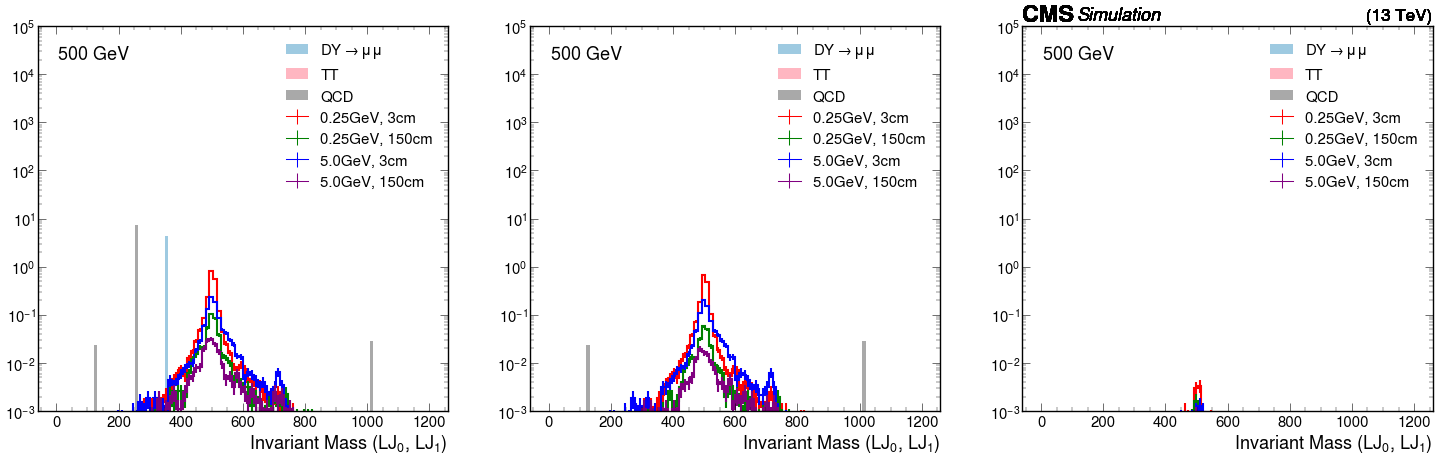

8 dsa_mulj_egmlj_invmass


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variance

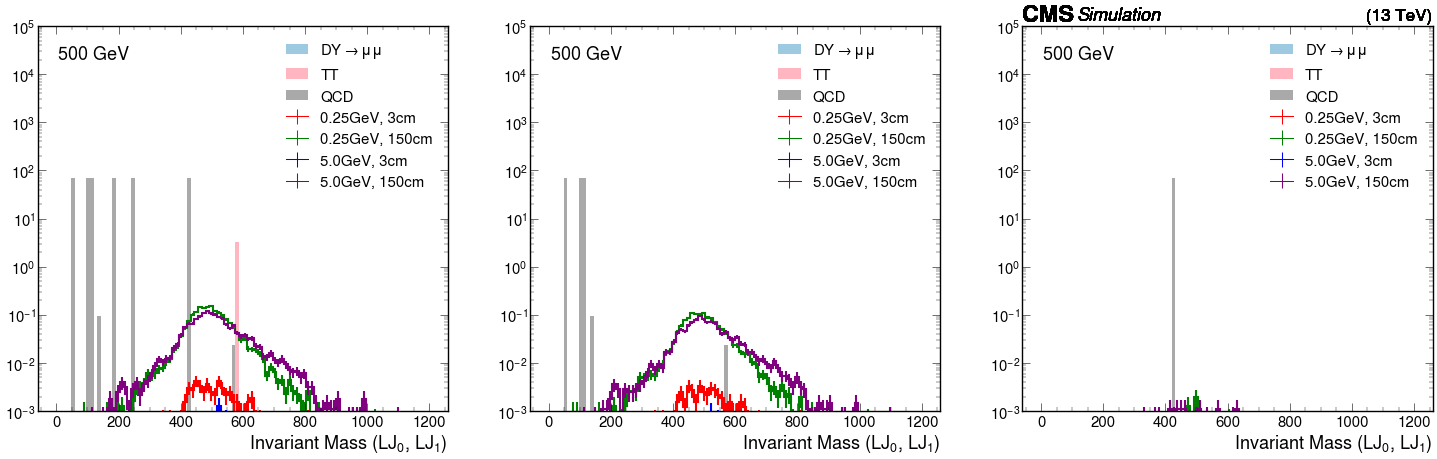

9 1pf_mulj_egmlj_invmass


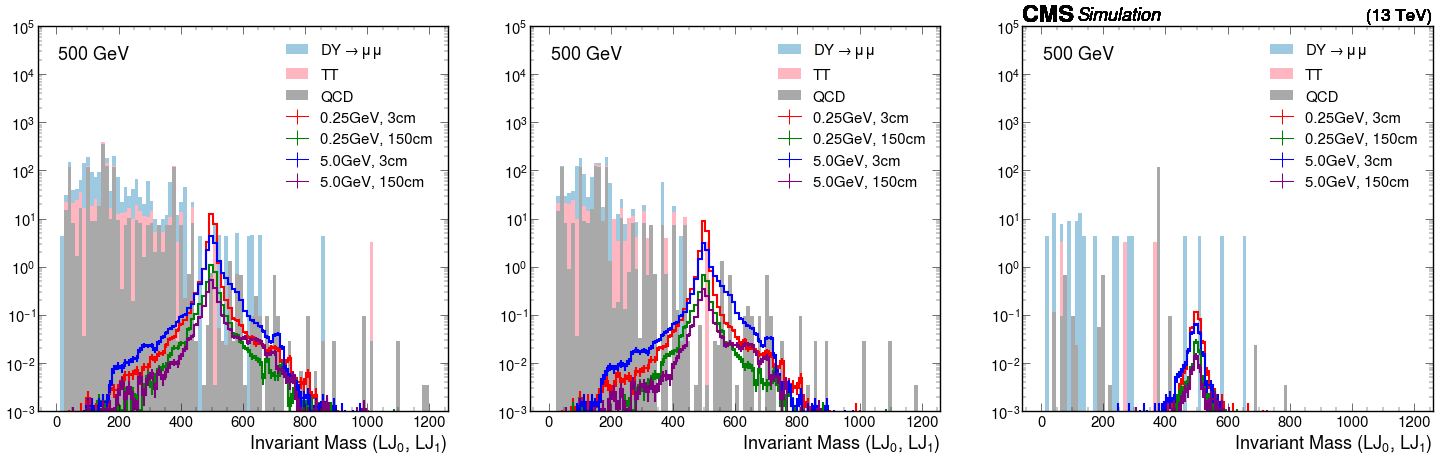

10 1pf_mulj_egmlj_invmass_trkLayers10


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


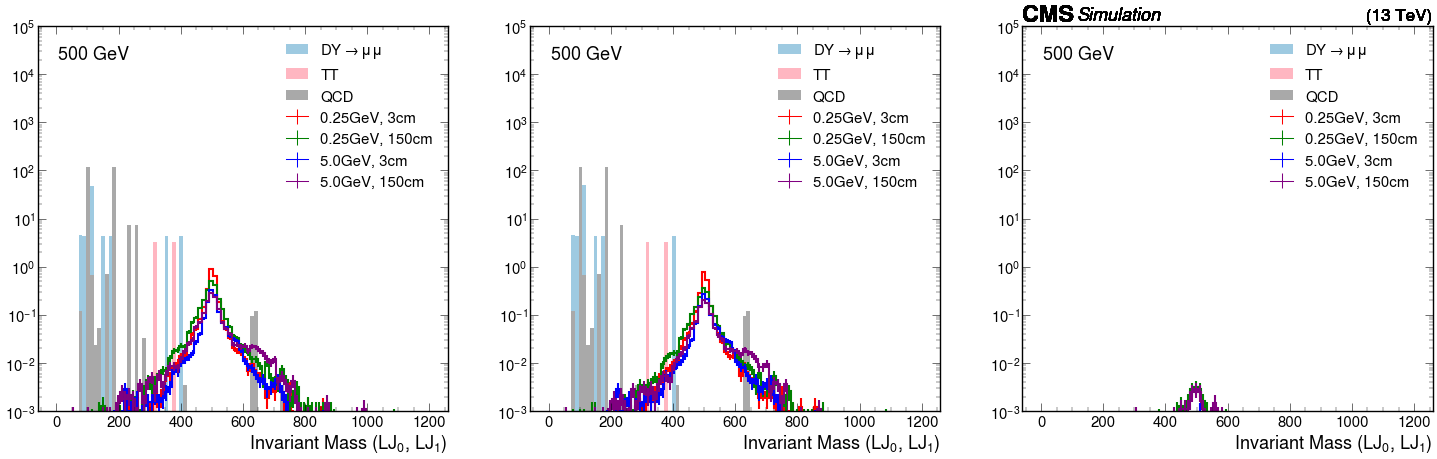

11 1pf_mulj_egmlj_invmass_trkLayers8


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


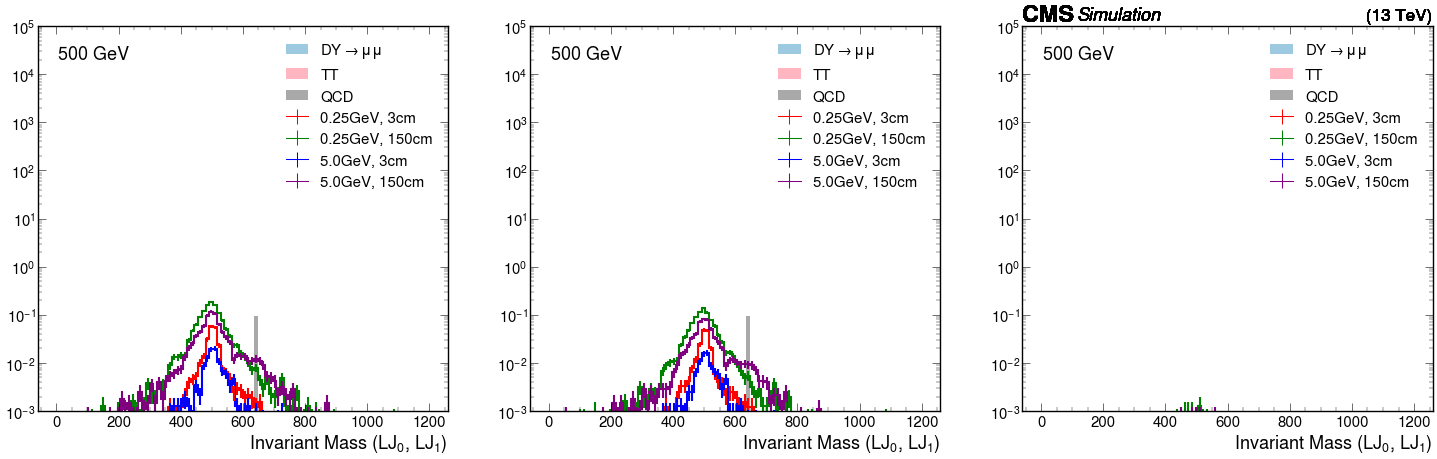

12 1pf_mulj_egmlj_invmass_pixelHits2


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


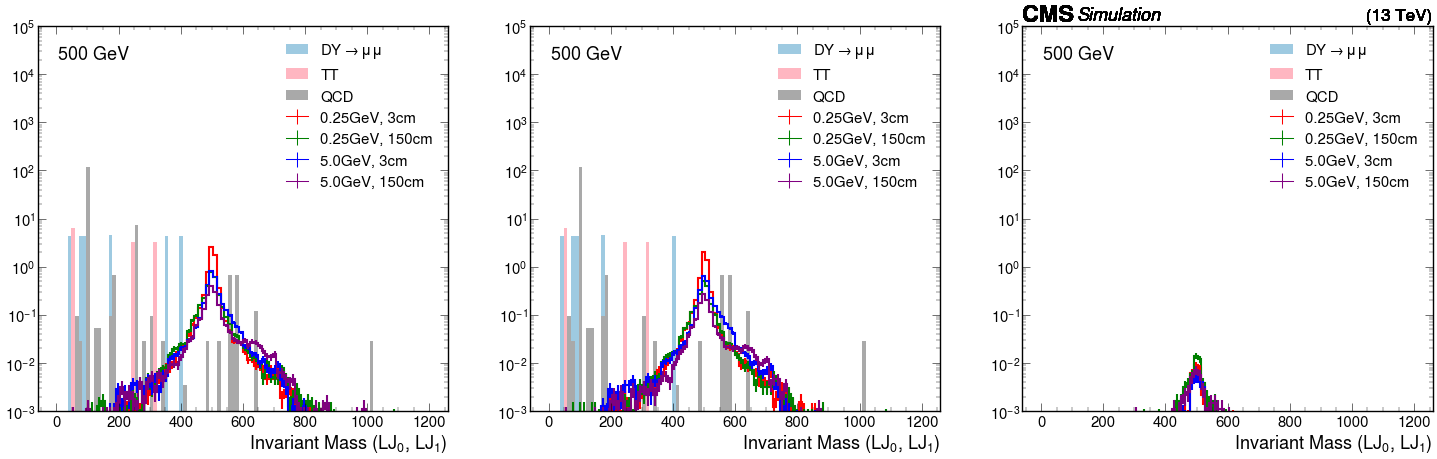

13 1pf_mulj_egmlj_invmass_pixelHits0


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


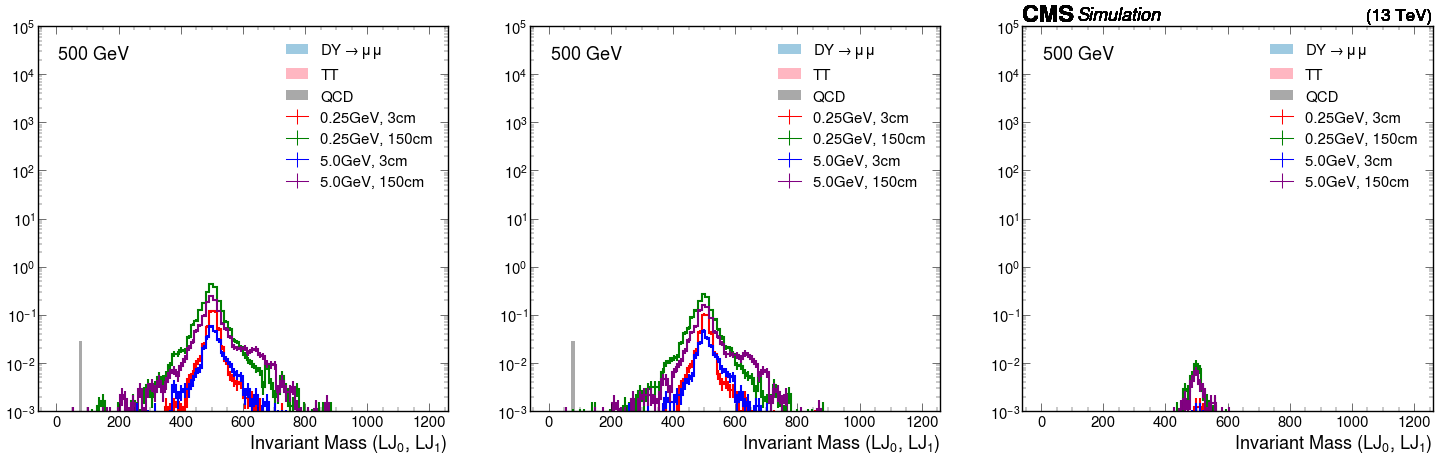

14 egm_lj_electron_min_dxy_XXXLowRange


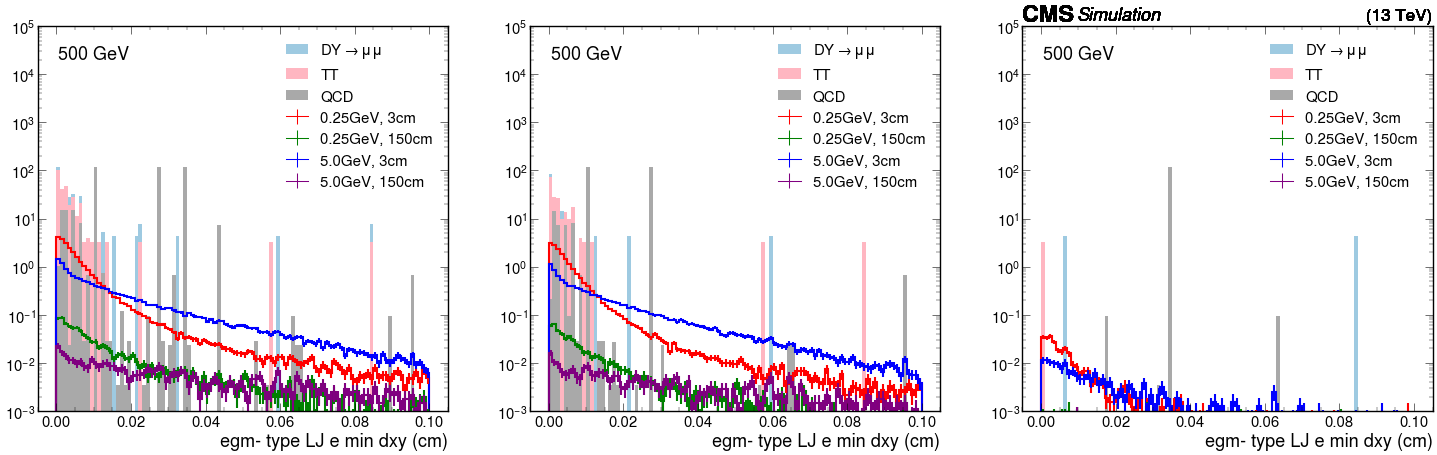

15 mulj_1e_lj_invmass


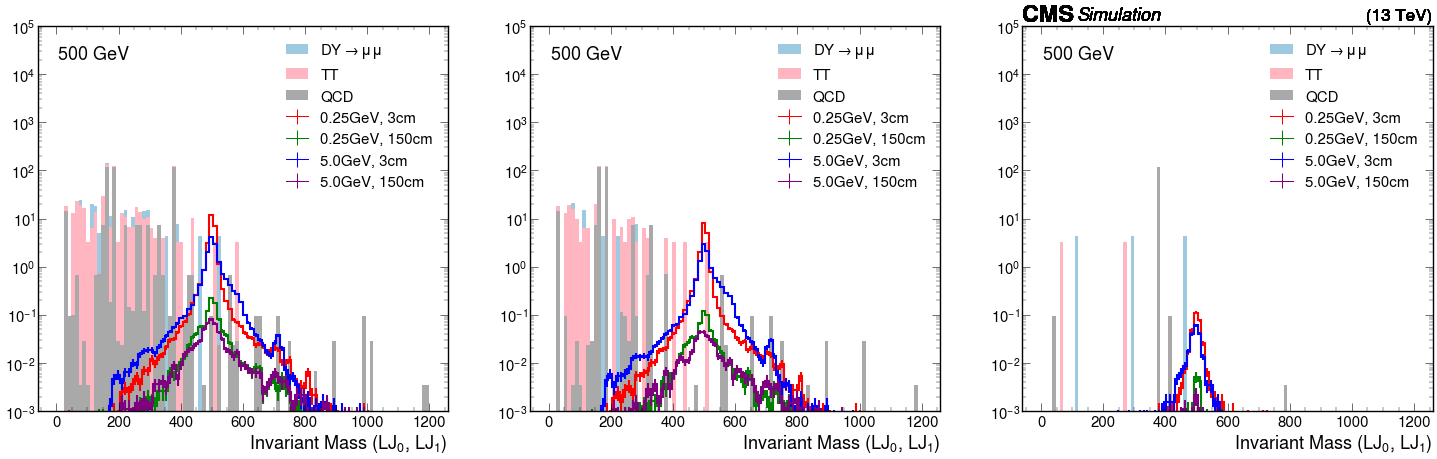

16 mulj_1e_lj_invmass_lostHits1


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


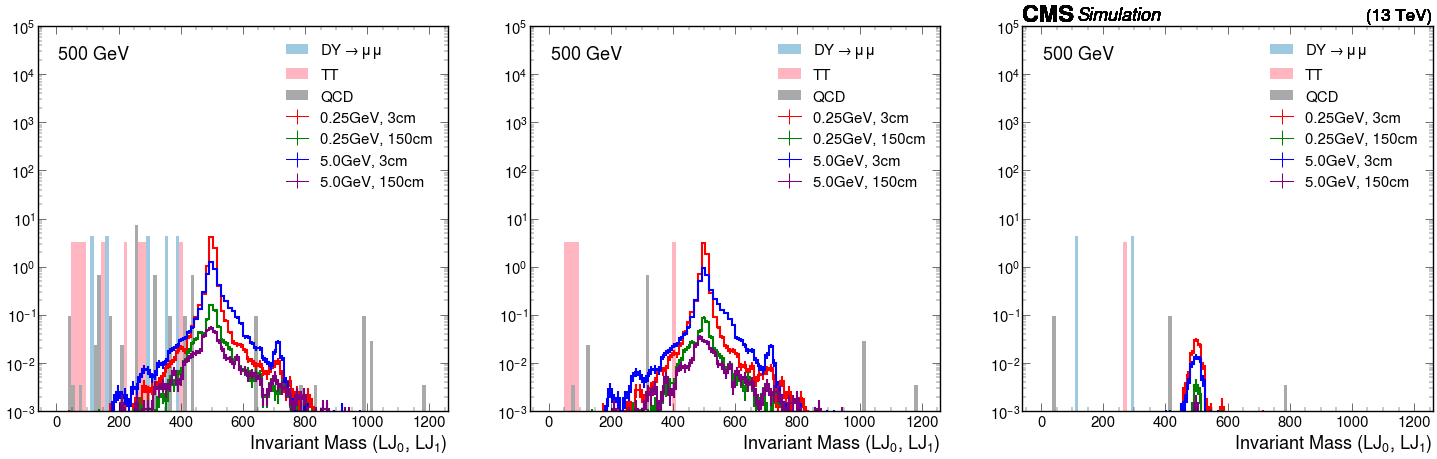

17 mulj_1e_lj_invmass_lostHits2


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


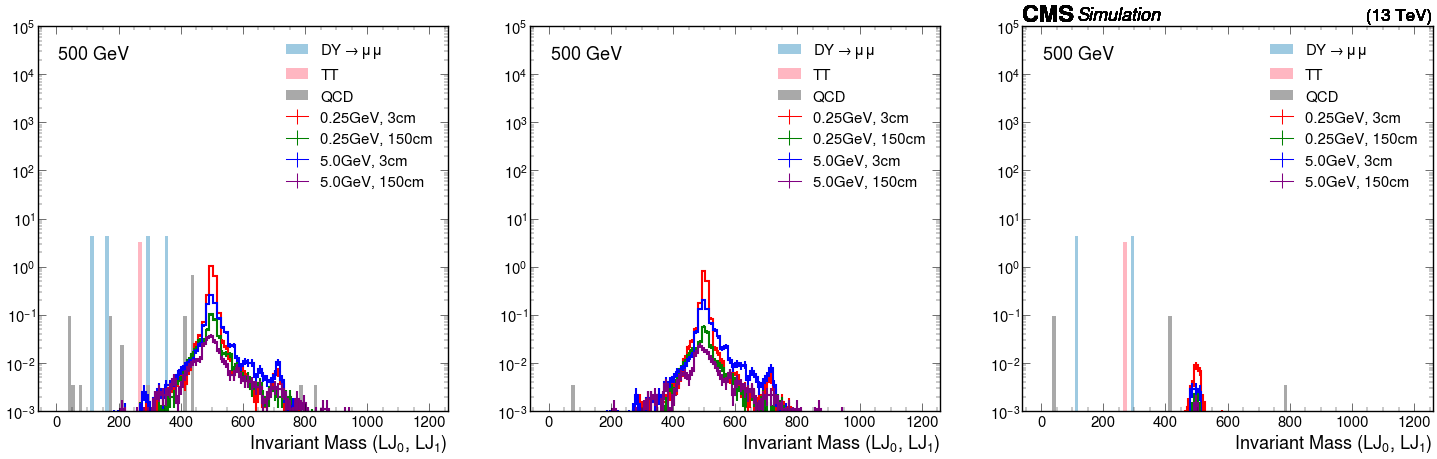

18 mulj_g_lj_invmass


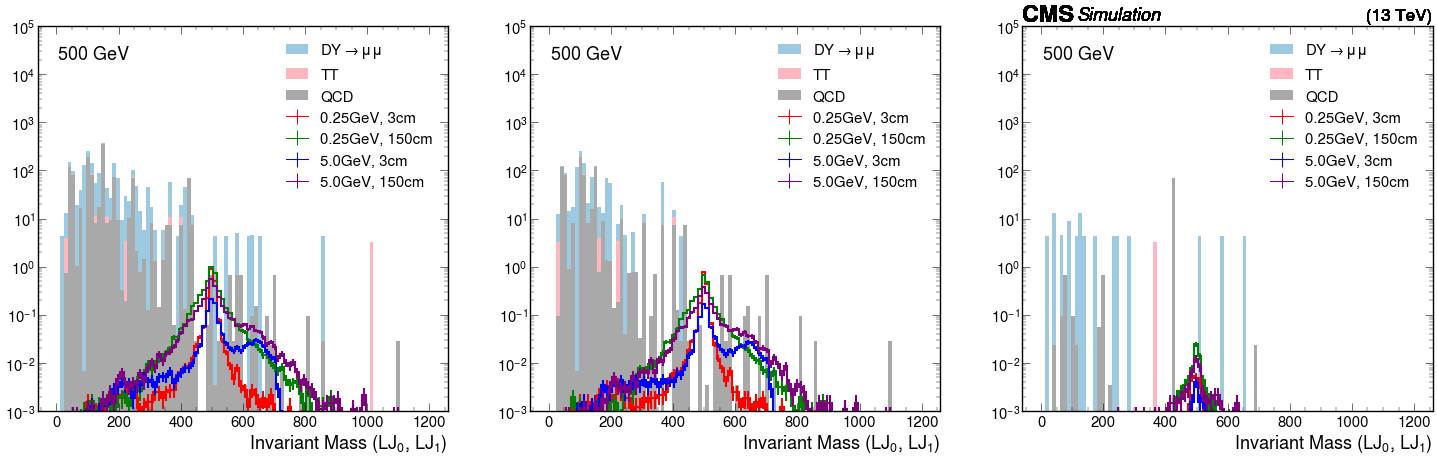

19 leading_mu_lj_pfMu_max_trkNumPixelHits


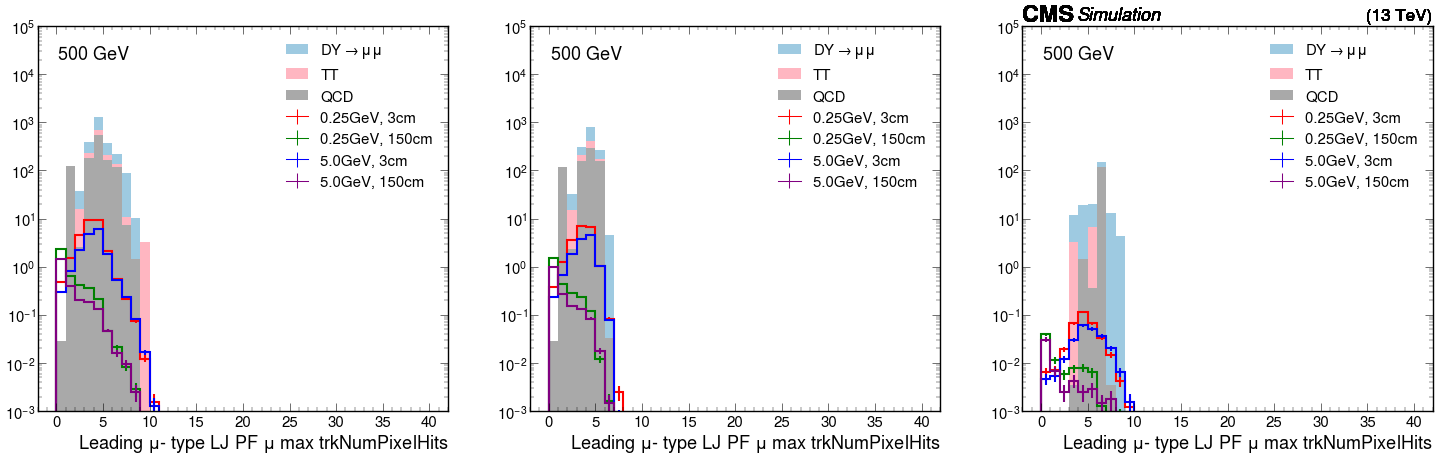

20 leading_mu_lj_pfMu_max_trkNumTrkLayers


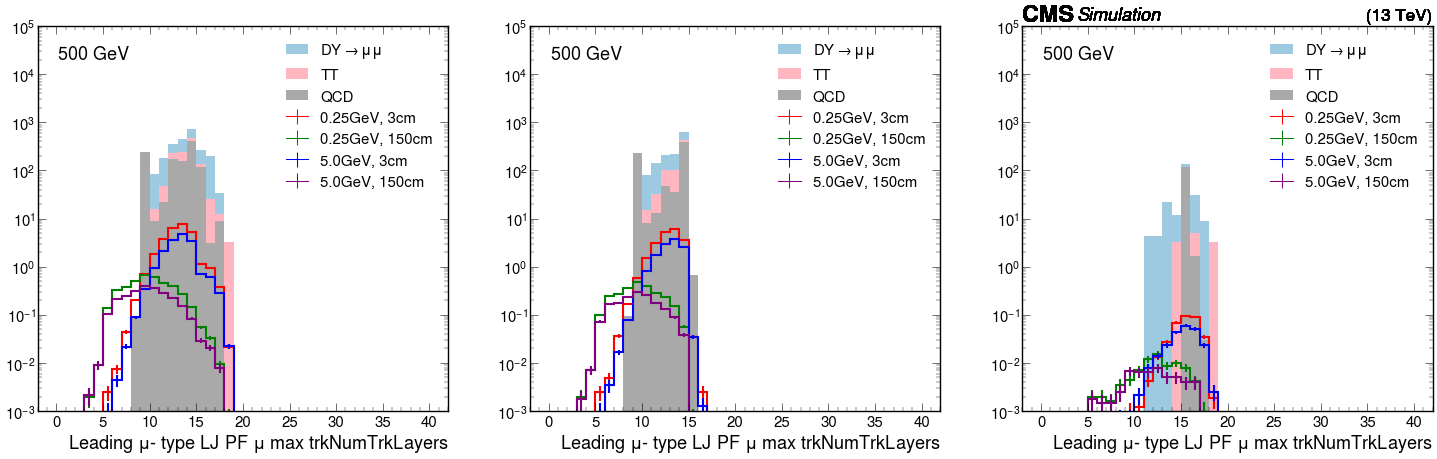

21 leading_egm_lj_electron_min_lostHits


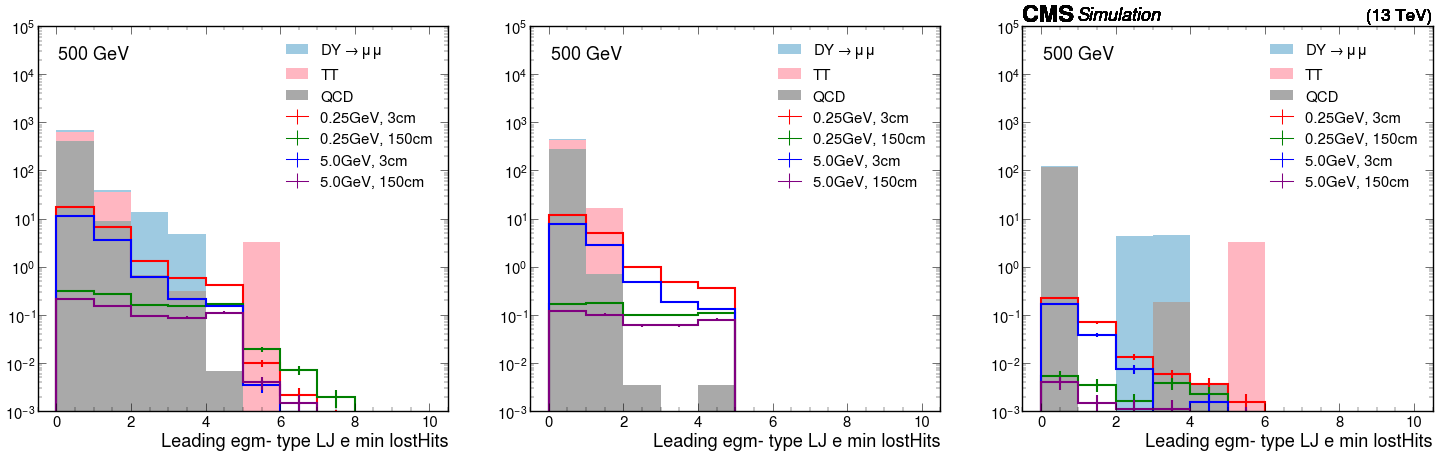

In [4]:
def sum_bgs_hist(bgs_list, histogram_name, channel_name, dir_path):
    """
    Sum histograms for a list of backgrounds.
    """
    summed_hist = None
    
    for x in bgs_list:
        # print(x)
        output_bg = coffea.util.load(f"{dir_path}/output_{x}.coffea")
        hist = output_bg["out"][x]["hists"][histogram_name][channel_name, :]
        
        if summed_hist is None:
            summed_hist = hist.copy()
        else:
            summed_hist += hist
    
    return summed_hist
channel_name = "base_ljObjCut_ljIso_2lj_barrel"

histogram_list  = [ 
 "mulj_egmlj_invmass",
"mu_lj_pfMuon_dxy_XLowRange",
"mu_lj_pfMuon_max_dxy_XLowRange",
"mu_lj_pfMuon_min_dxy_XLowRange",
"egm_lj_electron_dxy_XXXLowRange",
"egm_lj_electron_max_dxy_XXXLowRange",
 "egm_lj_electron_min_dxy_XXXLowRange",
 "mulj_egmlj_invmass_pixelHits_lostHits",
"dsa_mulj_egmlj_invmass",
"1pf_mulj_egmlj_invmass",

"1pf_mulj_egmlj_invmass_trkLayers10",

 "1pf_mulj_egmlj_invmass_trkLayers8",
"1pf_mulj_egmlj_invmass_pixelHits2",

"1pf_mulj_egmlj_invmass_pixelHits0",

 "egm_lj_electron_min_dxy_XXXLowRange",
 "mulj_1e_lj_invmass",
"mulj_1e_lj_invmass_lostHits1",
"mulj_1e_lj_invmass_lostHits2",

"mulj_g_lj_invmass",
"leading_mu_lj_pfMu_max_trkNumPixelHits",

"leading_mu_lj_pfMu_max_trkNumTrkLayers",
"leading_egm_lj_electron_min_lostHits",


]
S = [
   
'2Mu2E_500GeV_0p25GeV_0p04mm',
'2Mu2E_500GeV_0p25GeV_2p0mm',
'2Mu2E_500GeV_5p0GeV_0p8mm',
'2Mu2E_500GeV_5p0GeV_40p0mm',

]
channels =  ["base_ljObjCut_ljIso_2lj",
             "base_ljObjCut_ljIso_2lj_barrel", 
            "base_ljObjCut_ljIso_2lj_endcap"]
labels = ["3cm", "150cm", "3cm", "150cm"]
colors = ['r', 'g', 'b', 'purple']
# sum_bg = sum_bgs_hist(QCD, histogram_name,channel_name )
for i, histogram_name in enumerate(histogram_list):
    print(i, histogram_name)
    fig, axes = plt.subplots(1, 3, figsize=(36, 10))
    for j, channel_name in enumerate(channels):
        # print(channel_name)
        hist_collection = "displacement_base"
        dir_path = channel_name + hist_collection
        output_signal = coffea.util.load(f"{dir_path}/output_signal.coffea" )

        sum_bg_qcd = sum_bgs_hist(QCD, histogram_name,channel_name, dir_path )
        sum_bg_tt = sum_bgs_hist(TT, histogram_name,channel_name, dir_path )
        sum_bg_dy = sum_bgs_hist(DY, histogram_name,channel_name, dir_path )
    
        utilities.plot(
        [sum_bg_qcd, 
         sum_bg_tt,
          sum_bg_dy
        ],
        flow="none",
        yerr=True,
        density=False,
        histtype="fill",
        color=["#A9A9A9","#FFB6C1", "#9ECAE1"],
        label=["QCD", "TT",r"DY$\rightarrow\mu\mu$"],
        stack=True,
        ax = axes[j])
        for k, s in enumerate(S):
            # print(s)
            parts = s.split("_")
            mass = parts[1]
            zd_mass = parts[2].replace("p", ".")
            ctau = parts[3].replace("p", ".").replace("mm", "")
            label =  zd_mass + ", " + labels[k]
            histogram = output_signal["out"][s]["hists"][histogram_name][channel_name, :]
            utilities.plot(histogram, flow ="none", yerr=True, density=False, label=label, color=colors[k], linewidth=3,ax=axes[j])
        hep.label.exp_text(text="500 GeV ", loc=3, ax=axes[j]) 
        axes[j].set_yscale("log")
        axes[j].legend()
        axes[j].set_ylim(1e-3, 1e5)
    plt.show()
    plt.close()